# Лабораторная работа №1
## Освоение базового ML-пайплайна на табличных данных

**Выполнил:** Шалыгин Ярослав

**Датасет:** [Student Depression and Lifestyle 100k Data](https://www.kaggle.com/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data)

**Цель работы:** Построить воспроизводимый ML-пайплайн для табличных данных, выполнить EDA, предобработку, генерацию признаков и обучить модели линейной регрессии (CGPA) и логистической регрессии (Depression).

# 0. Загрузка датасета

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('student_lifestyle_100k.csv')
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


# 1. Разведочный анализ данных с визуализациями

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [3]:
print("Типы данных в столбцах:", end="\n\n")
print(df.dtypes)

Типы данных в столбцах:

Student_ID              int64
Age                     int64
Gender                 object
Department             object
CGPA                  float64
Sleep_Duration        float64
Study_Hours           float64
Social_Media_Hours    float64
Physical_Activity       int64
Stress_Level            int64
Depression               bool
dtype: object


In [4]:
print("Количество пропущенных значений в каждом столбце:", end="\n\n")
print(df.isnull().sum())

Количество пропущенных значений в каждом столбце:

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64


In [5]:
# Проверка логических ошибок: сумма часов > 24
invalid_time_mask = (df["Sleep_Duration"] + df["Study_Hours"] + df["Social_Media_Hours"] > 24)
print(f"Количество строк с суммой часов > 24: {invalid_time_mask.sum()}")

df.drop(index=df[invalid_time_mask].index, inplace=True)
print(f"Размер датасета после удаления логических ошибок: {df.shape}")

Количество строк с суммой часов > 24: 79
Размер датасета после удаления логических ошибок: (99921, 11)


In [6]:
# Удаляем Student_ID — не несёт полезной информации
df.drop(columns=["Student_ID"], inplace=True)
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [7]:
print('До:', df.shape)
n_duplicates = df.duplicated().sum()
if n_duplicates == 0:
    print("Дублей нет")
else:
    print(f"Количество дублей: {n_duplicates}")
    df.drop_duplicates(inplace=True)
print('После:', df.shape)

До: (99921, 10)
Дублей нет
После: (99921, 10)


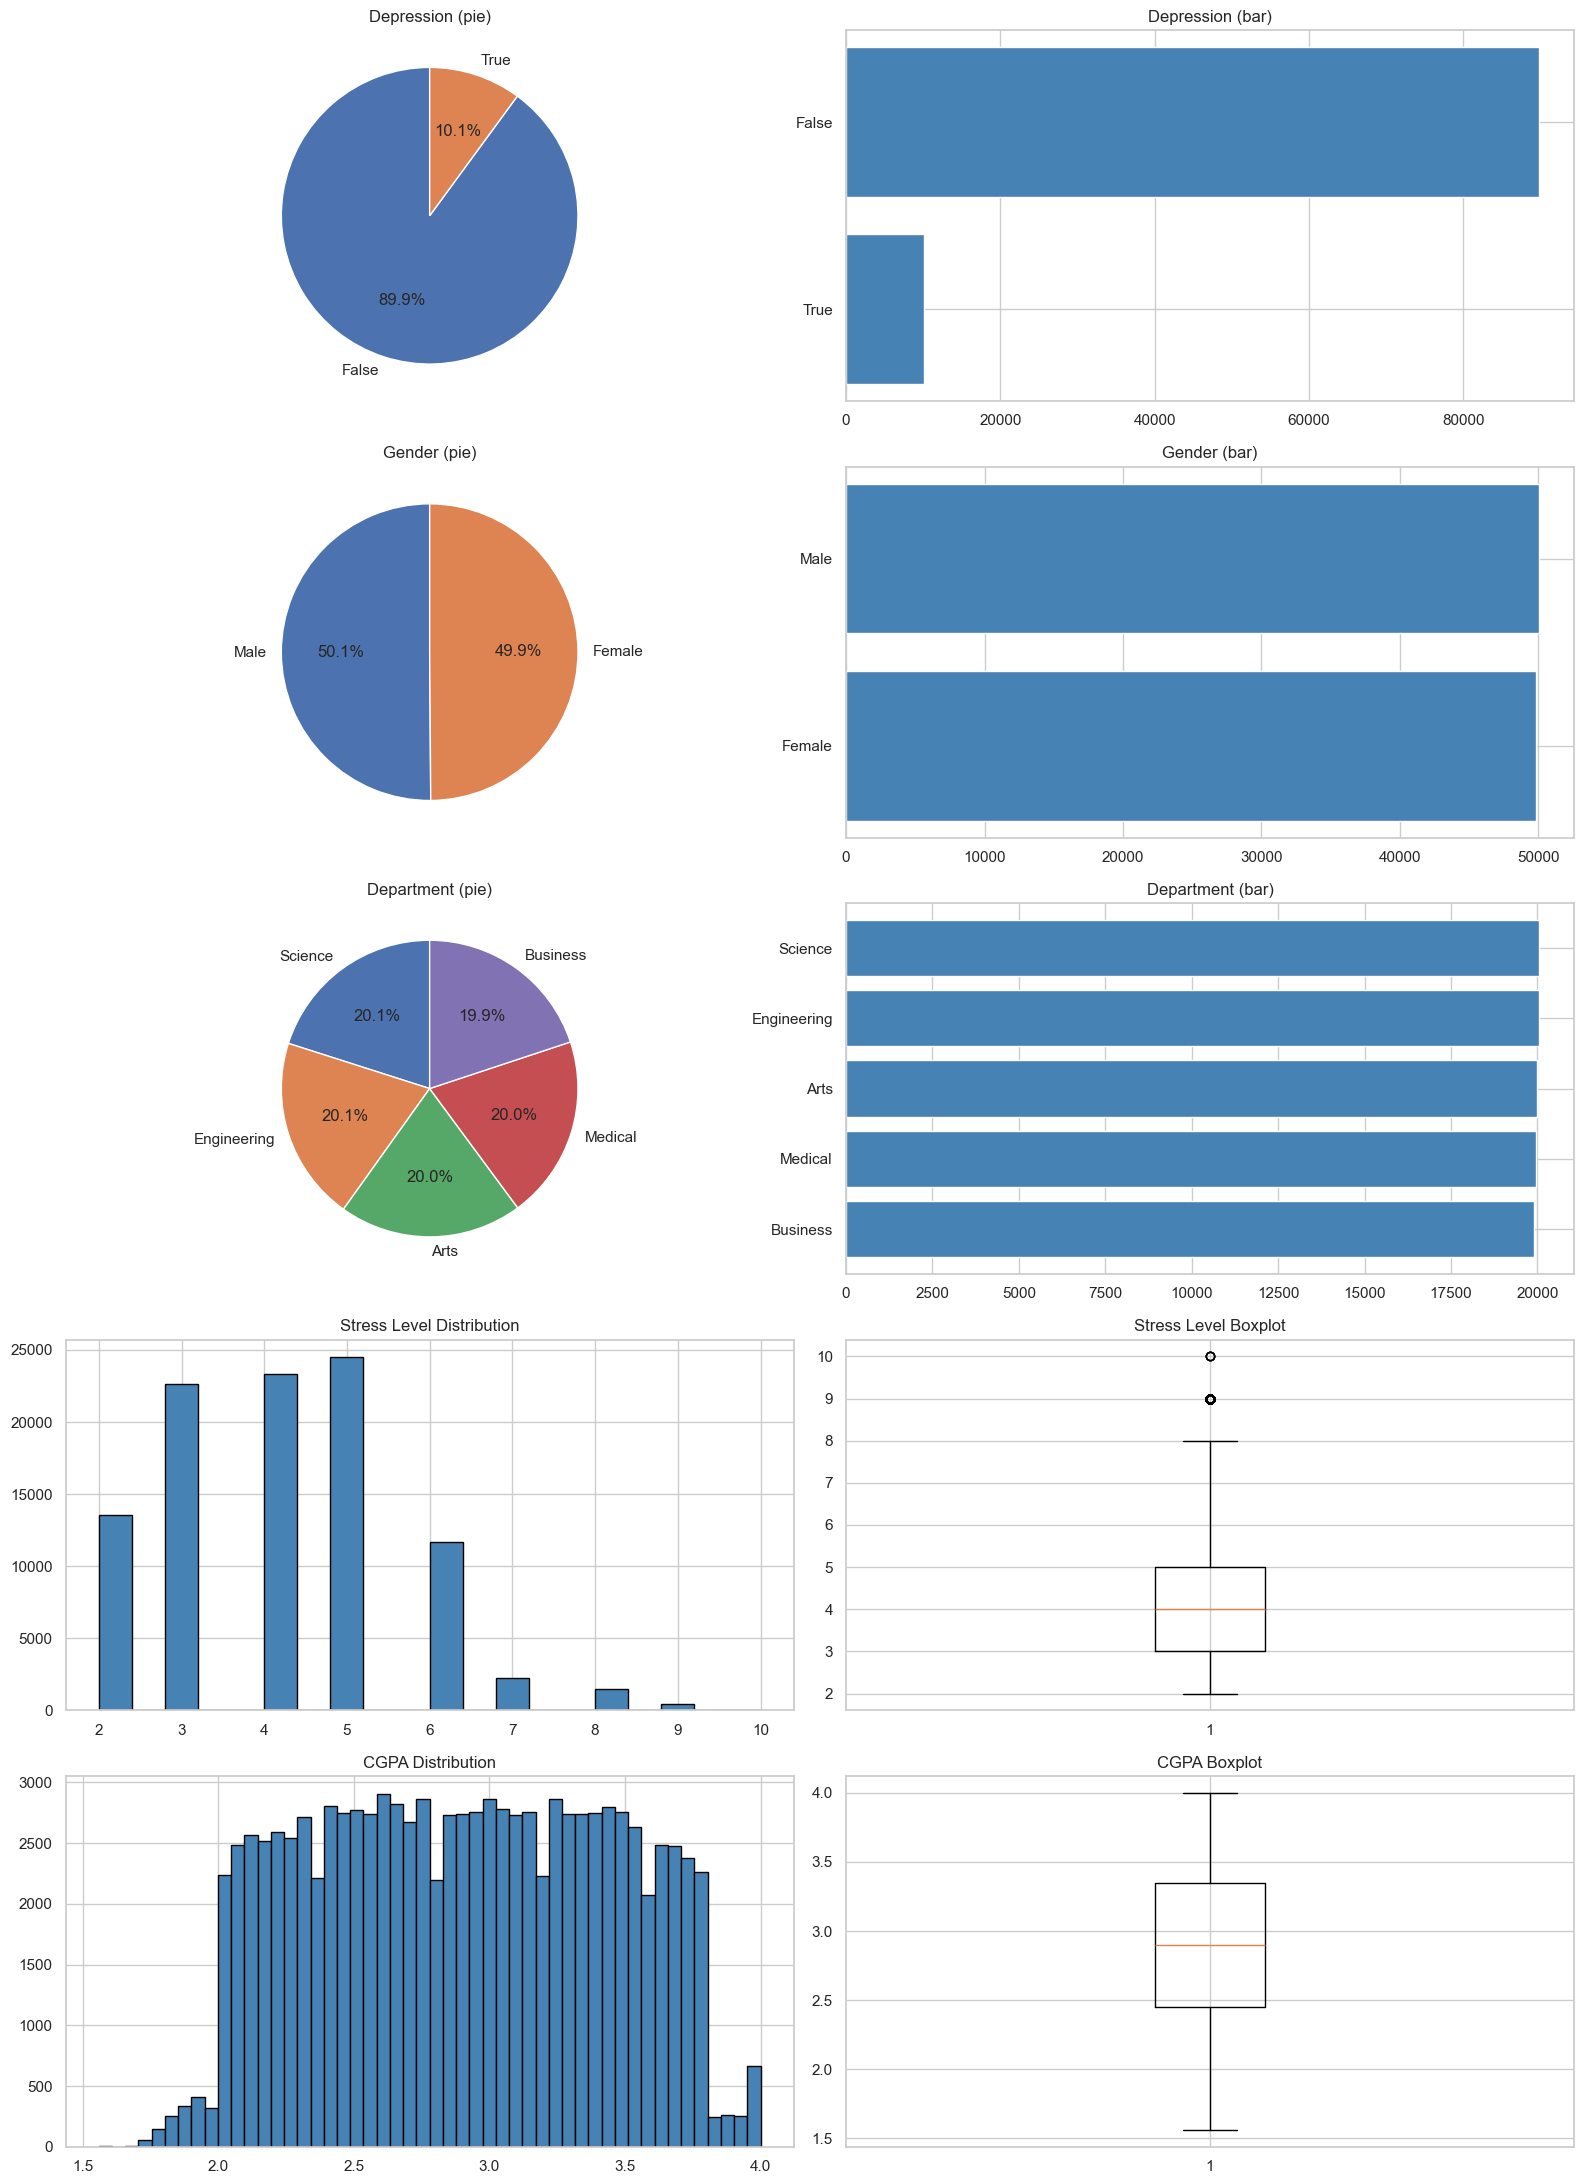

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(5, 2, figsize=(16, 22))

def plot_pie_and_barh(ax_pie, ax_barh, counts, title, colors=None):
    labels = counts.index.astype(str)
    values = counts.values
    ax_pie.pie(values, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors)
    ax_pie.set_title(f"{title} (pie)")
    ax_barh.barh(labels, values, color=colors or 'steelblue')
    ax_barh.set_title(f"{title} (bar)")
    ax_barh.invert_yaxis()

# Depression
dep_counts = df['Depression'].value_counts()
plot_pie_and_barh(axes[0,0], axes[0,1], dep_counts, "Depression")

# Gender
gen_counts = df['Gender'].value_counts()
plot_pie_and_barh(axes[1,0], axes[1,1], gen_counts, "Gender")

# Department
dept_counts = df['Department'].value_counts()
plot_pie_and_barh(axes[2,0], axes[2,1], dept_counts, "Department")

# Stress level
stress_counts = df['Stress_Level'].value_counts().sort_index()
axes[3,0].hist(df['Stress_Level'], bins=20, edgecolor='black', color='steelblue')
axes[3,0].set_title('Stress Level Distribution')
axes[3,1].boxplot(df['Stress_Level'])
axes[3,1].set_title('Stress Level Boxplot')

# CGPA
axes[4,0].hist(df['CGPA'], bins=50, edgecolor='black', color='steelblue')
axes[4,0].set_title('CGPA Distribution')
axes[4,1].boxplot(df['CGPA'].dropna())
axes[4,1].set_title('CGPA Boxplot')

plt.tight_layout()
plt.show()

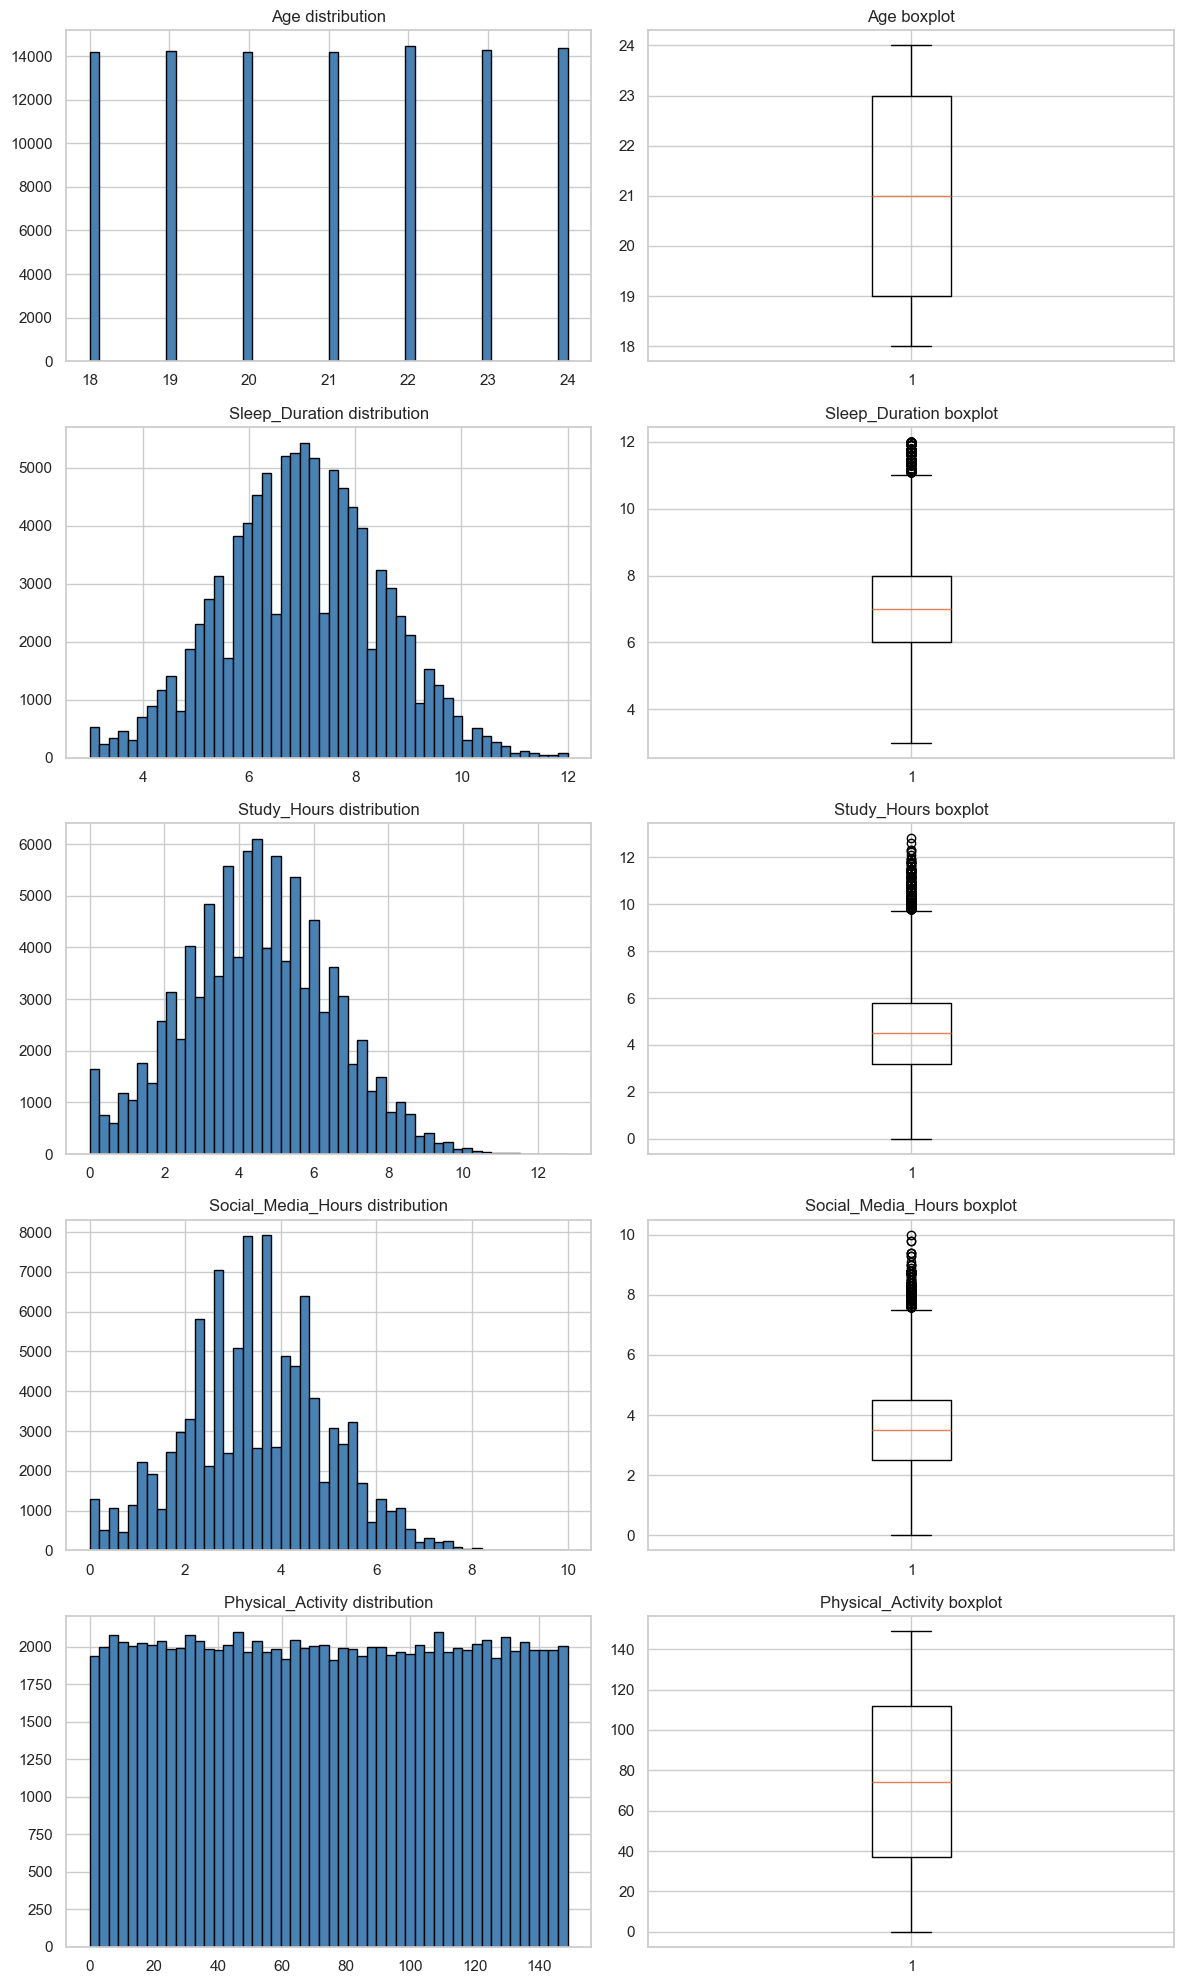

In [9]:
# Распределения числовых признаков
num_cols = ['Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity']
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4*len(num_cols)))
for i, col in enumerate(num_cols):
    axes[i,0].hist(df[col].dropna(), bins=50, edgecolor='black', color='steelblue')
    axes[i,0].set_title(f'{col} distribution')
    axes[i,1].boxplot(df[col].dropna())
    axes[i,1].set_title(f'{col} boxplot')
plt.tight_layout()
plt.show()

# 2. Обработка пропусков и кодирование категориальных признаков

In [10]:
print("Количество пропущенных значений:", df.isnull().sum().sum())

Количество пропущенных значений: 0


In [11]:
from sklearn.preprocessing import OneHotEncoder

# Кодировка бинарных признаков
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})
df["Depression"] = df["Depression"].astype(int)

# OneHotEncoding для Department
ohe = OneHotEncoder(sparse_output=False, drop="first")
dept_encoded = ohe.fit_transform(df[["Department"]])
dept_df = pd.DataFrame(
    dept_encoded,
    columns=ohe.get_feature_names_out(["Department"]),
    index=df.index
)
df = pd.concat([df.drop(columns=["Department"]), dept_df], axis=1)
df.head()

,Age,Gender,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,22,0,3.50,7.3,3.3,3.4,114,5,0,0.0,0.0,0.0,1.0
1,20,1,2.72,5.5,7.2,6.0,142,2,0,0.0,1.0,0.0,0.0
2,20,1,3.01,5.4,2.3,1.8,137,3,0,0.0,0.0,1.0,0.0
3,21,1,3.63,8.1,2.0,4.6,130,3,0,0.0,1.0,0.0,0.0
4,19,1,3.14,6.8,2.6,4.3,4,6,0,0.0,0.0,0.0,0.0


# 3. Feature engineering

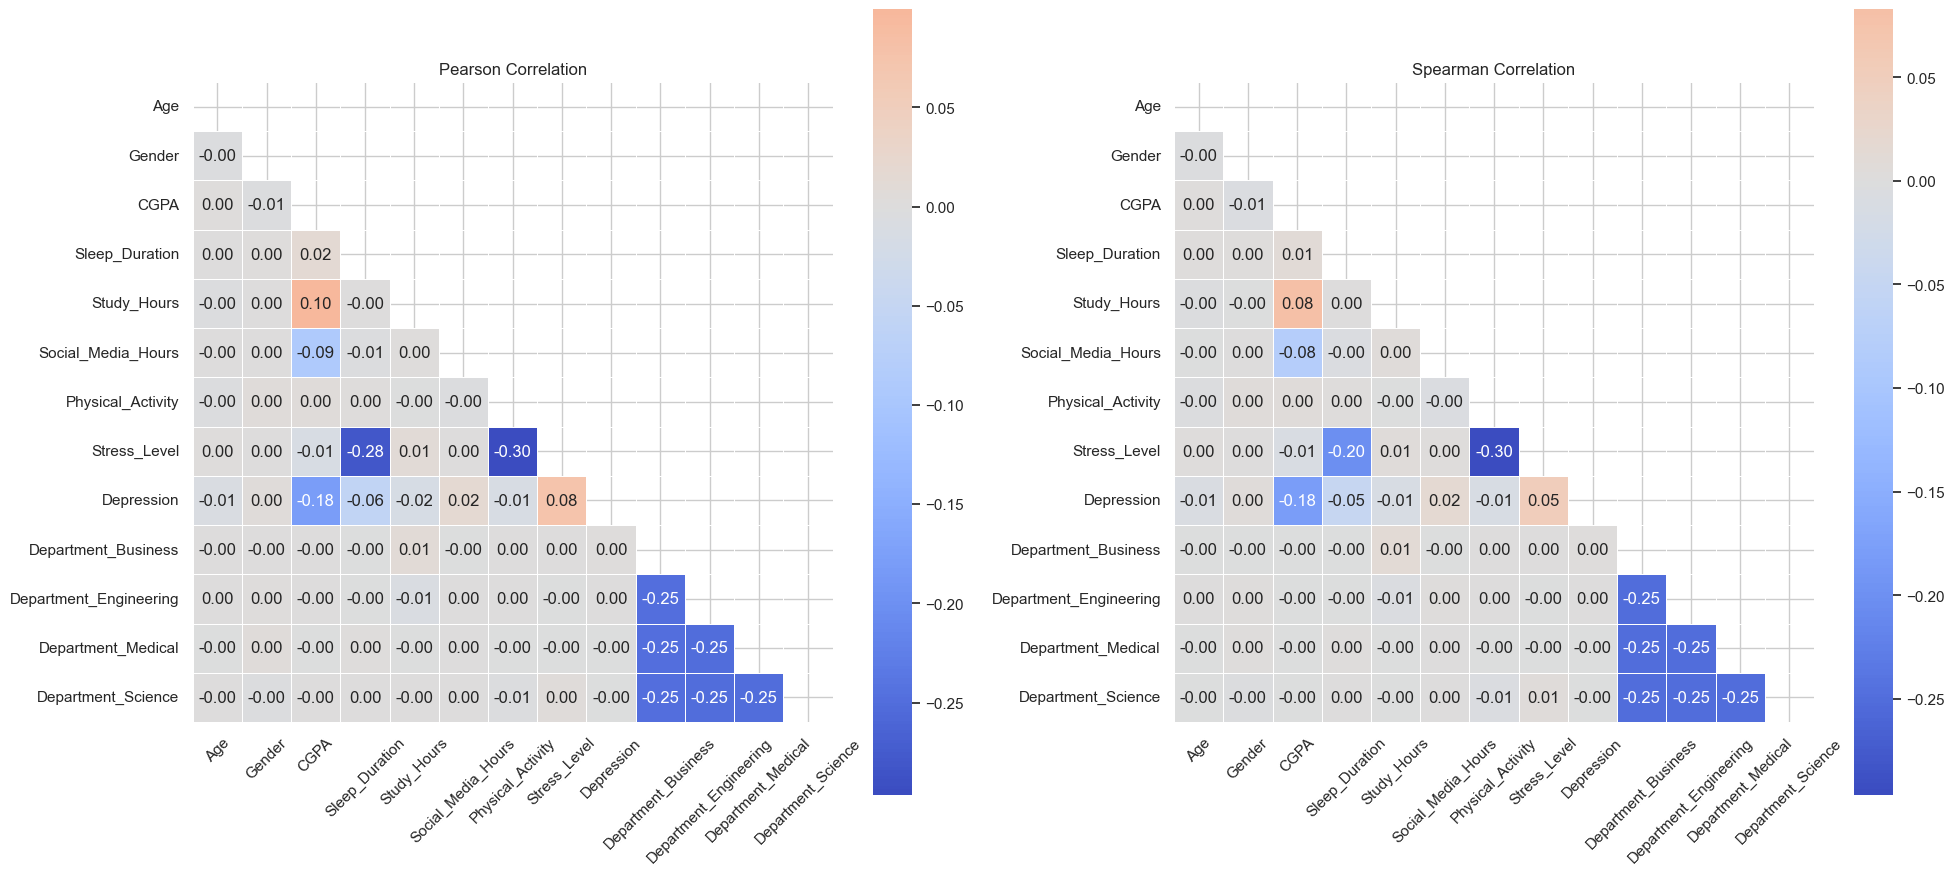

In [12]:
# Корреляции
pearson_corr = df.corr(method="pearson")
spearman_corr = df.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

sns.heatmap(pearson_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title("Pearson Correlation")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(spearman_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title("Spearman Correlation")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Для регрессии (CGPA) взяты признаки: Sleep_Duration, Study_Hours, Social_Media_Hours, Stress_Level, Depression — как основные факторы режима занятий и сна.

Для классификации (Depression): Sleep_Duration, Study_Hours, Social_Media_Hours, Physical_Activity, Stress_Level, CGPA — образ жизни и уровень стресса.

In [13]:
reg_features = ["Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Stress_Level", "Depression"]
clf_features = ["Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Stress_Level", "Physical_Activity", "CGPA"]

print("Признаки для CGPA:", reg_features)
print("Признаки для Depression:", clf_features)

Признаки для CGPA: ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level', 'Depression']
Признаки для Depression: ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level', 'Physical_Activity', 'CGPA']


# 4. Разделение данных

In [14]:
from sklearn.model_selection import train_test_split

# 70/15/15 split со стратификацией по Depression
train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df["Depression"])
train_df, val_df = train_test_split(train_val_df, test_size=0.1765, random_state=42, stratify=train_val_df["Depression"])

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

Train: (69941, 13), Val: (14991, 13), Test: (14989, 13)


In [15]:
# Данные для регрессии
X_reg_train = train_df[reg_features]
X_reg_val = val_df[reg_features]
X_reg_test = test_df[reg_features]
y_reg_train = train_df["CGPA"]
y_reg_val = val_df["CGPA"]
y_reg_test = test_df["CGPA"]

# Данные для классификации
X_clf_train = train_df[clf_features]
X_clf_val = val_df[clf_features]
X_clf_test = test_df[clf_features]
y_clf_train = train_df["Depression"].astype(int)
y_clf_val = val_df["Depression"].astype(int)
y_clf_test = test_df["Depression"].astype(int)

print(f"Reg train: {X_reg_train.shape}, y: {y_reg_train.shape}")
print(f"Clf train: {X_clf_train.shape}, y: {y_clf_train.shape}")

Reg train: (69941, 5), y: (69941,)
Clf train: (69941, 6), y: (69941,)


# 5. Линейная регрессия для CGPA

## 5.1 Коррекция выбросов

In [16]:
# Коррекция выбросов только по обучающей выборке (IQR метод)
train_mask = pd.Series(True, index=X_reg_train.index)
val_mask = pd.Series(True, index=X_reg_val.index)
test_mask = pd.Series(True, index=X_reg_test.index)

for col in reg_features:
    if X_reg_train[col].nunique() <= 2:
        continue
    q1 = X_reg_train[col].quantile(0.25)
    q3 = X_reg_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    train_mask &= X_reg_train[col].between(lower, upper)
    val_mask &= X_reg_val[col].between(lower, upper)
    test_mask &= X_reg_test[col].between(lower, upper)

X_reg_train_clean = X_reg_train[train_mask]
y_reg_train_clean = y_reg_train[train_mask]
X_reg_val_clean = X_reg_val[val_mask]
y_reg_val_clean = y_reg_val[val_mask]
X_reg_test_clean = X_reg_test[test_mask]
y_reg_test_clean = y_reg_test[test_mask]

print(f"Удалено выбросов: train={len(X_reg_train)-len(X_reg_train_clean)}, val={len(X_reg_val)-len(X_reg_val_clean)}, test={len(X_reg_test)-len(X_reg_test_clean)}")

Удалено выбросов: train=1101, val=239, test=200


## 5.2 Масштабирование

In [17]:
from sklearn.preprocessing import StandardScaler

reg_scale_cols = [c for c in reg_features if X_reg_train[c].nunique() > 2]

scaler_reg = StandardScaler()
X_reg_train_sc = X_reg_train.copy()
X_reg_val_sc = X_reg_val.copy()
X_reg_test_sc = X_reg_test.copy()

X_reg_train_sc[reg_scale_cols] = scaler_reg.fit_transform(X_reg_train[reg_scale_cols])
X_reg_val_sc[reg_scale_cols] = scaler_reg.transform(X_reg_val[reg_scale_cols])
X_reg_test_sc[reg_scale_cols] = scaler_reg.transform(X_reg_test[reg_scale_cols])

print("Масштабируемые признаки:", reg_scale_cols)

Масштабируемые признаки: ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level']


## 5.3 Обучение модели и метрики

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

lr_model = LinearRegression()
lr_model.fit(X_reg_train_sc, y_reg_train)

y_reg_train_pred = lr_model.predict(X_reg_train_sc)
y_reg_val_pred = lr_model.predict(X_reg_val_sc)
y_reg_test_pred = lr_model.predict(X_reg_test_sc)

def regression_metrics(y_true, y_pred, prefix):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{prefix}: MAE={mae:.4f}, MAPE={mape:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")
    return {'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2}

reg_metrics = {}
reg_metrics['Train'] = regression_metrics(y_reg_train, y_reg_train_pred, 'Train')
reg_metrics['Valid'] = regression_metrics(y_reg_val, y_reg_val_pred, 'Valid')
reg_metrics['Test'] = regression_metrics(y_reg_test, y_reg_test_pred, 'Test')

Train: MAE=0.4449, MAPE=0.1616, RMSE=0.5193, R2=0.0464
Valid: MAE=0.4420, MAPE=0.1606, RMSE=0.5170, R2=0.0554
Test: MAE=0.4452, MAPE=0.1620, RMSE=0.5201, R2=0.0525


## 5.4 Коэффициенты модели

In [19]:
reg_coef_df = pd.DataFrame({
    "Feature": X_reg_train_sc.columns,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient")
print(reg_coef_df)

              Feature  Coefficient
4          Depression    -0.302594
2  Social_Media_Hours    -0.043424
3        Stress_Level     0.002059
0      Sleep_Duration     0.002882
1         Study_Hours     0.051700


## 5.5 Визуализации

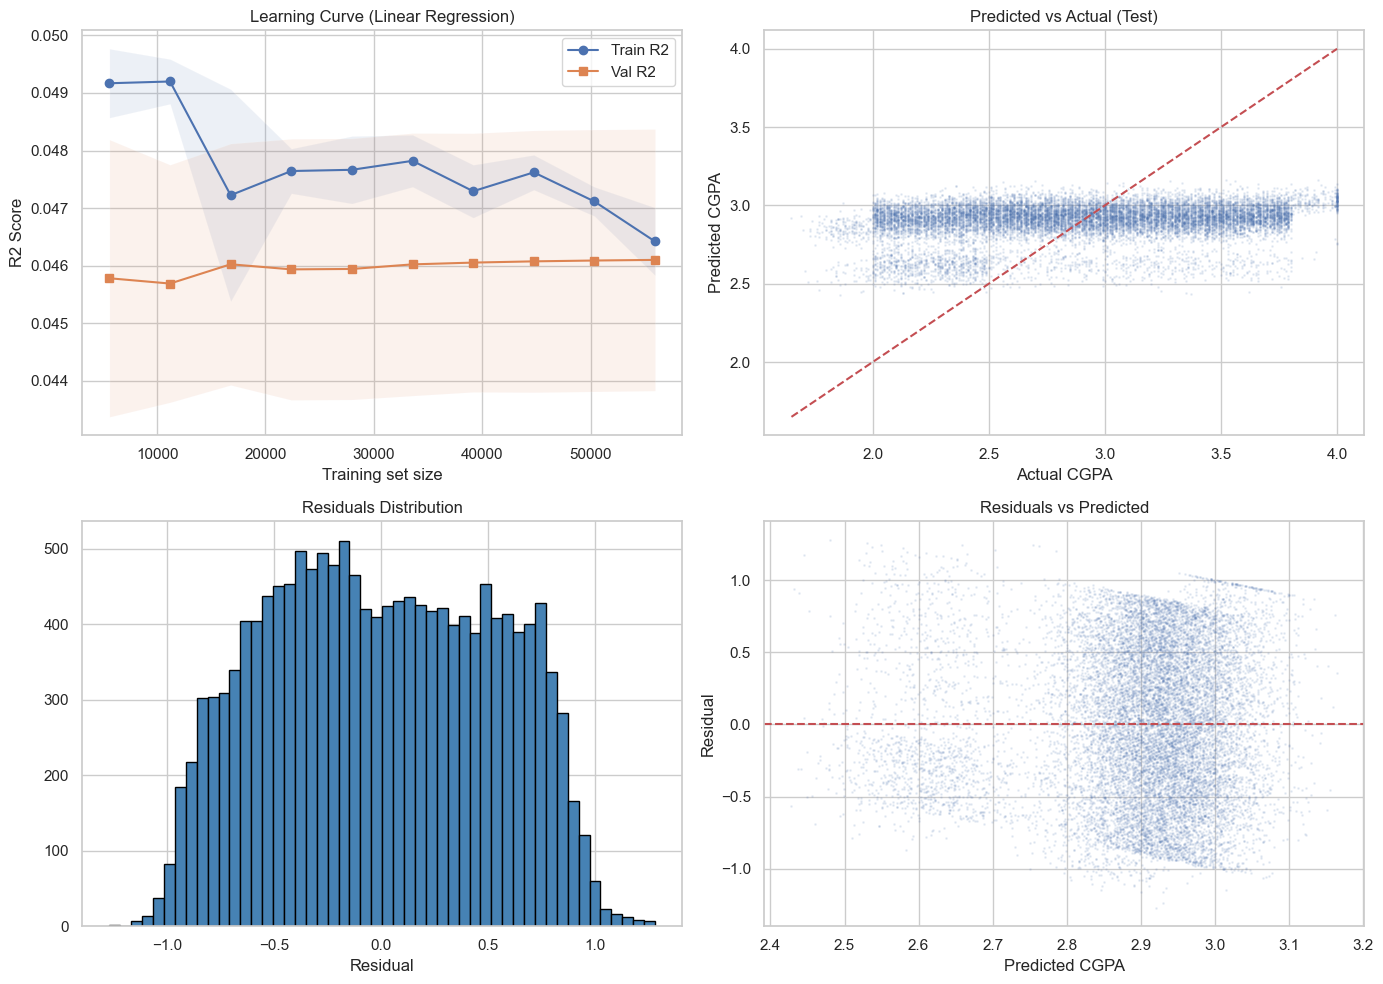

In [20]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X_reg_train_sc, y_reg_train,
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), scoring="r2", n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

axes[0,0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
axes[0,0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
axes[0,0].plot(train_sizes, train_mean, 'o-', label='Train R2')
axes[0,0].plot(train_sizes, val_mean, 's-', label='Val R2')
axes[0,0].set_title('Learning Curve (Linear Regression)')
axes[0,0].set_xlabel('Training set size')
axes[0,0].set_ylabel('R2 Score')
axes[0,0].legend()

# Predicted vs Actual
axes[0,1].scatter(y_reg_test, y_reg_test_pred, alpha=0.1, s=1)
min_v = min(y_reg_test.min(), y_reg_test_pred.min())
max_v = max(y_reg_test.max(), y_reg_test_pred.max())
axes[0,1].plot([min_v, max_v], [min_v, max_v], 'r--')
axes[0,1].set_xlabel('Actual CGPA')
axes[0,1].set_ylabel('Predicted CGPA')
axes[0,1].set_title('Predicted vs Actual (Test)')

# Residuals histogram
residuals = y_reg_test - y_reg_test_pred
axes[1,0].hist(residuals, bins=50, edgecolor='black', color='steelblue')
axes[1,0].set_title('Residuals Distribution')
axes[1,0].set_xlabel('Residual')

# Residuals vs Predicted
axes[1,1].scatter(y_reg_test_pred, residuals, alpha=0.1, s=1)
axes[1,1].axhline(y=0, color='r', linestyle='--')
axes[1,1].set_xlabel('Predicted CGPA')
axes[1,1].set_ylabel('Residual')
axes[1,1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

## 5.6 CGPA на моих данных

In [21]:
my_data = pd.DataFrame([{
    "Sleep_Duration": 7,
    "Study_Hours": 8,
    "Social_Media_Hours": 2,
    "Stress_Level": 3,
    "Depression": 0
}])
my_data[reg_scale_cols] = scaler_reg.transform(my_data[reg_scale_cols])
my_cgpa = lr_model.predict(my_data)
print(f"Предсказанный CGPA: {my_cgpa[0]:.3f}")

Предсказанный CGPA: 3.063


# 6. Логистическая регрессия для Depression

## 6.1 Коррекция выбросов

In [22]:
train_mask_c = pd.Series(True, index=X_clf_train.index)
val_mask_c = pd.Series(True, index=X_clf_val.index)
test_mask_c = pd.Series(True, index=X_clf_test.index)

for col in clf_features:
    q1 = X_clf_train[col].quantile(0.25)
    q3 = X_clf_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    train_mask_c &= X_clf_train[col].between(lower, upper)
    val_mask_c &= X_clf_val[col].between(lower, upper)
    test_mask_c &= X_clf_test[col].between(lower, upper)

X_clf_train_c = X_clf_train[train_mask_c]
y_clf_train_c = y_clf_train[train_mask_c]
X_clf_val_c = X_clf_val[val_mask_c]
y_clf_val_c = y_clf_val[val_mask_c]
X_clf_test_c = X_clf_test[test_mask_c]
y_clf_test_c = y_clf_test[test_mask_c]

print(f"Выбросов удалено: train={len(X_clf_train)-len(X_clf_train_c)}, val={len(X_clf_val)-len(X_clf_val_c)}, test={len(X_clf_test)-len(X_clf_test_c)}")

Выбросов удалено: train=1101, val=239, test=200


## 6.2 Масштабирование

In [23]:
clf_scale_cols = clf_features
scaler_clf = StandardScaler()

X_clf_train_sc = X_clf_train.copy()
X_clf_val_sc = X_clf_val.copy()
X_clf_test_sc = X_clf_test.copy()

X_clf_train_sc[clf_scale_cols] = scaler_clf.fit_transform(X_clf_train[clf_scale_cols])
X_clf_val_sc[clf_scale_cols] = scaler_clf.transform(X_clf_val[clf_scale_cols])
X_clf_test_sc[clf_scale_cols] = scaler_clf.transform(X_clf_test[clf_scale_cols])

print("Масштабируемые признаки:", clf_scale_cols)

Масштабируемые признаки: ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level', 'Physical_Activity', 'CGPA']


## 6.3 Кастомная логистическая регрессия

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

class LogisticRegressionCustom:
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42, penalty='l2', alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.penalty = penalty
        self.alpha = alpha
        self.weights = None
        self.bias = 0
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for i in range(self.n_iterations):
            linear = np.dot(X, self.weights) + self.bias
            predictions = self._sigmoid(linear)
            eps = 1e-15
            loss = -np.mean(y * np.log(predictions + eps) + (1 - y) * np.log(1 - predictions + eps))
            self.loss_history.append(loss)

            dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
            db = (1 / n_samples) * np.sum(predictions - y)

            # L2 regularization
            if self.penalty == 'l2':
                dw += self.alpha * self.weights

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_proba(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

### 6.3.1 Определение learning rate и числа эпох

In [25]:
X_train_np = X_clf_train_sc.to_numpy(dtype=float)
X_val_np = X_clf_val_sc.to_numpy(dtype=float)
X_test_np = X_clf_test_sc.to_numpy(dtype=float)
y_train_np = y_clf_train.to_numpy()
y_val_np = y_clf_val.to_numpy()
y_test_np = y_clf_test.to_numpy()

learning_rates = [0.0001, 0.001, 0.003, 0.005, 0.01]
epochs_list = [50, 100, 300, 500, 1000]

exp_results = []

for lr in learning_rates:
    for epochs in epochs_list:
        model = LogisticRegressionCustom(learning_rate=lr, n_iterations=epochs, random_state=42, penalty='l2', alpha=0.01)
        model.fit(X_train_np, y_train_np)
        
        y_val_pred = model.predict(X_val_np, threshold=0.5)
        y_val_proba = model.predict_proba(X_val_np)
        
        val_f1 = f1_score(y_val_np, y_val_pred, zero_division=0)
        val_auc = roc_auc_score(y_val_np, y_val_proba) if len(np.unique(y_val_np)) > 1 else 0.5
        
        exp_results.append({'lr': lr, 'epochs': epochs, 'f1': val_f1, 'auc': val_auc})

exp_df = pd.DataFrame(exp_results)
print(exp_df.to_string(index=False))

    lr  epochs  f1      auc
0.0001      50 0.0 0.688272
0.0001     100 0.0 0.688278
0.0001     300 0.0 0.688310
0.0001     500 0.0 0.688339
0.0001    1000 0.0 0.688420
0.0010      50 0.0 0.688339
0.0010     100 0.0 0.688420
0.0010     300 0.0 0.688722
0.0010     500 0.0 0.689012
0.0010    1000 0.0 0.689683
0.0030      50 0.0 0.688495
0.0030     100 0.0 0.688720
0.0030     300 0.0 0.689552
0.0030     500 0.0 0.690256
0.0030    1000 0.0 0.691606
0.0050      50 0.0 0.688647
0.0050     100 0.0 0.689005
0.0050     300 0.0 0.690255
0.0050     500 0.0 0.691223
0.0050    1000 0.0 0.692683
0.0100      50 0.0 0.689001
0.0100     100 0.0 0.689673
0.0100     300 0.0 0.691603
0.0100     500 0.0 0.692683
0.0100    1000 0.0 0.694019


In [26]:
best_idx = exp_df['f1'].idxmax()
best_lr = exp_df.loc[best_idx]['lr']
best_epochs = int(exp_df.loc[best_idx]['epochs'])
print(f"Лучшие: lr={best_lr}, epochs={best_epochs}, F1={exp_df.loc[best_idx]['f1']:.4f}")

Лучшие: lr=0.0001, epochs=50, F1=0.0000


## 6.4 Обучение лучшей модели и метрики

In [27]:
def evaluate_classification(y_true, y_pred, y_proba, prefix):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)
    print(f"{prefix}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={auc:.4f}")
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}

best_clf = LogisticRegressionCustom(learning_rate=best_lr, n_iterations=best_epochs, random_state=42, penalty='l2', alpha=0.01)
best_clf.fit(X_train_np, y_train_np)

y_train_proba = best_clf.predict_proba(X_train_np)
y_val_proba = best_clf.predict_proba(X_val_np)
y_test_proba = best_clf.predict_proba(X_test_np)

y_train_pred = best_clf.predict(X_train_np)
y_val_pred = best_clf.predict(X_val_np)
y_test_pred = best_clf.predict(X_test_np)

clf_metrics = {}
clf_metrics['Train'] = evaluate_classification(y_train_np, y_train_pred, y_train_proba, 'Train')
clf_metrics['Valid'] = evaluate_classification(y_val_np, y_val_pred, y_val_proba, 'Valid')
clf_metrics['Test'] = evaluate_classification(y_test_np, y_test_pred, y_test_proba, 'Test')

Train: Acc=0.8994, Prec=0.0000, Rec=0.0000, F1=0.0000, AUC=0.6773
Valid: Acc=0.8993, Prec=0.0000, Rec=0.0000, F1=0.0000, AUC=0.6883
Test: Acc=0.8993, Prec=0.0000, Rec=0.0000, F1=0.0000, AUC=0.6854


## 6.5 Коэффициенты модели

In [28]:
clf_coef_df = pd.DataFrame({
    "Feature": clf_features,
    "Coefficient": best_clf.weights
}).sort_values("Coefficient")
print(clf_coef_df)

              Feature  Coefficient
5                CGPA    -0.000262
0      Sleep_Duration    -0.000089
1         Study_Hours    -0.000024
4   Physical_Activity    -0.000019
2  Social_Media_Hours     0.000025
3        Stress_Level     0.000119


## 6.6 Визуализации

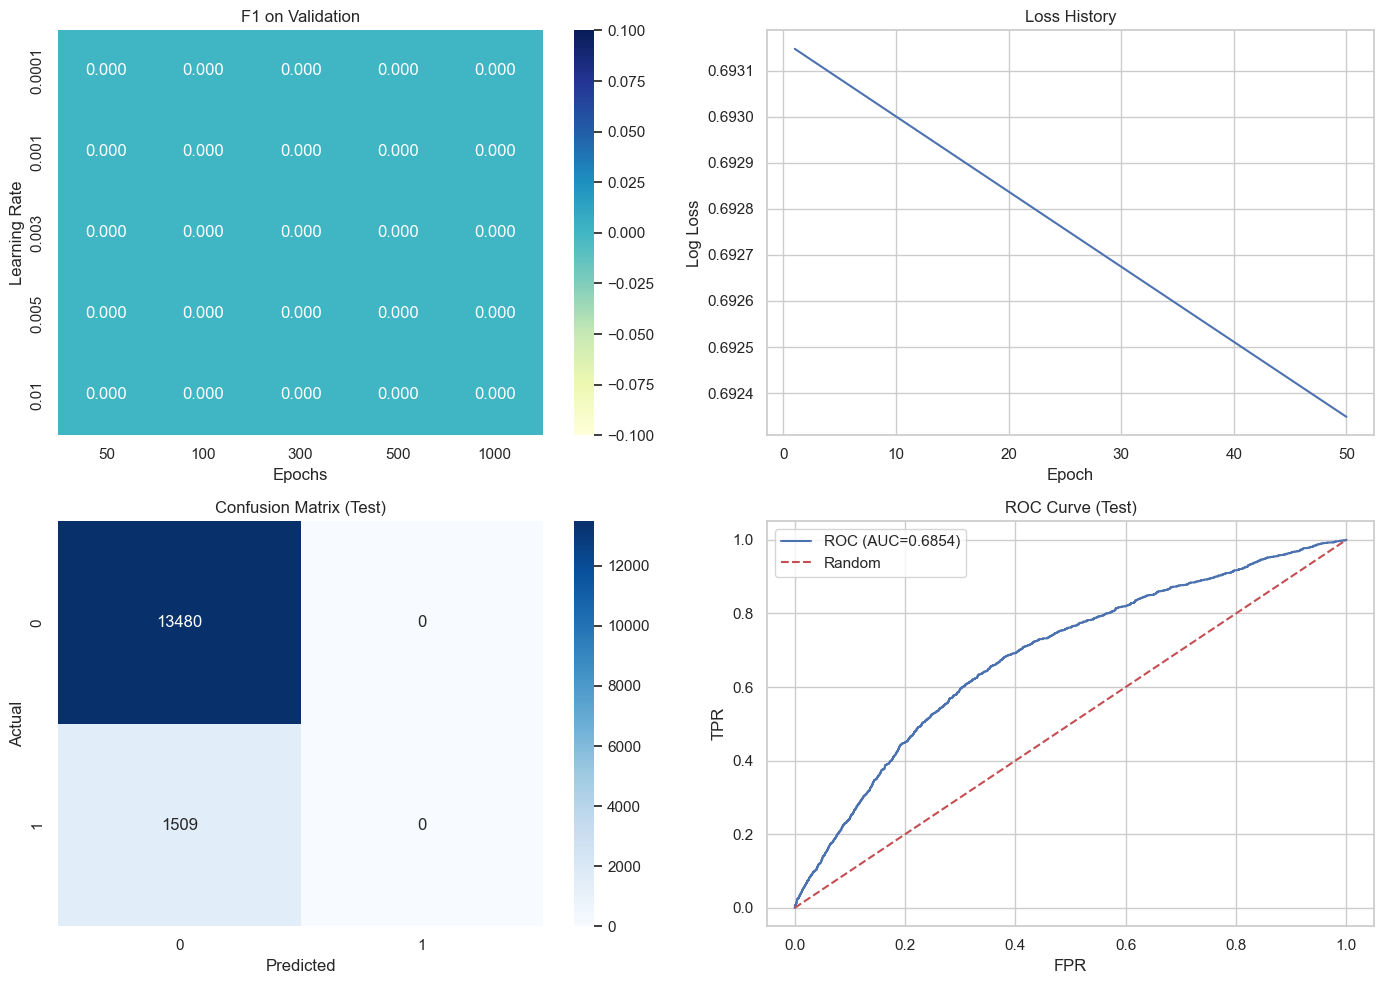

In [29]:
from sklearn.metrics import confusion_matrix, roc_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# F1 heatmap
f1_pivot = exp_df.pivot(index="lr", columns="epochs", values="f1")
sns.heatmap(f1_pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0,0])
axes[0,0].set_title("F1 on Validation")
axes[0,0].set_xlabel("Epochs")
axes[0,0].set_ylabel("Learning Rate")

# Loss history
axes[0,1].plot(range(1, len(best_clf.loss_history)+1), best_clf.loss_history)
axes[0,1].set_title('Loss History')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Log Loss')

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0])
axes[1,0].set_title('Confusion Matrix (Test)')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_np, y_test_proba)
auc_val = roc_auc_score(y_test_np, y_test_proba)
axes[1,1].plot(fpr, tpr, label=f'ROC (AUC={auc_val:.4f})')
axes[1,1].plot([0,1], [0,1], 'r--', label='Random')
axes[1,1].set_xlabel('FPR')
axes[1,1].set_ylabel('TPR')
axes[1,1].set_title('ROC Curve (Test)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 6.7 Depression на моих данных

In [30]:
my_clf = pd.DataFrame([{
    "Sleep_Duration": 7,
    "Study_Hours": 8,
    "Social_Media_Hours": 2,
    "Stress_Level": 3,
    "Physical_Activity": 30,
    "CGPA": 3.4
}])
my_clf[clf_scale_cols] = scaler_clf.transform(my_clf[clf_scale_cols])
my_proba = best_clf.predict_proba(my_clf.to_numpy(dtype=float))[0]
my_pred = int(my_proba >= 0.5)
print(f"Вероятность Depression: {my_proba:.4f}")
print(f"Предсказание: {'Depression' if my_pred == 1 else 'No Depression'}")

Вероятность Depression: 0.4994
Предсказание: No Depression


# 7. Проверка на переобучение

In [31]:
print("Диагностика:")
print(f"  Epochs: {best_epochs}")
print(f"  LR: {best_lr}")
print(f"  Penalty: L2 (alpha=0.01)")
print(f"  Final Loss: {best_clf.loss_history[-1]:.4f}")

acc_diff_tv = abs(clf_metrics['Train']['Accuracy'] - clf_metrics['Valid']['Accuracy'])
acc_diff_tt = abs(clf_metrics['Train']['Accuracy'] - clf_metrics['Test']['Accuracy'])
f1_diff_tv = abs(clf_metrics['Train']['F1'] - clf_metrics['Valid']['F1'])
f1_diff_tt = abs(clf_metrics['Train']['F1'] - clf_metrics['Test']['F1'])

print(f"\nAccuracy diff (train-val): {acc_diff_tv:.4f}")
print(f"Accuracy diff (train-test): {acc_diff_tt:.4f}")
print(f"F1 diff (train-val): {f1_diff_tv:.4f}")
print(f"F1 diff (train-test): {f1_diff_tt:.4f}")

if f1_diff_tv < 0.05 and f1_diff_tt < 0.05:
    print("\nOK: Переобучение не выявлено")
else:
    print("\nWARNING: Есть признаки переобучения")

Диагностика:
  Epochs: 50
  LR: 0.0001
  Penalty: L2 (alpha=0.01)
  Final Loss: 0.6923

Accuracy diff (train-val): 0.0000
Accuracy diff (train-test): 0.0000
F1 diff (train-val): 0.0000
F1 diff (train-test): 0.0000

OK: Переобучение не выявлено


Отсутствие переобучения проверялось по разнице метрик между train/val/test.
Если бы модель переобучилась, F1 и AUC на train были бы существенно выше.
Различия малы — переобучения нет.

# 8. Оценка качества моделей

In [32]:
print("\nЛинейная регрессия (CGPA):")
for split, metrics in reg_metrics.items():
    print(f"  {split}: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R2={metrics['R2']:.4f}")

print("\nЛогистическая регрессия (Depression):")
for split, metrics in clf_metrics.items():
    print(f"  {split}: Acc={metrics['Accuracy']:.4f}, F1={metrics['F1']:.4f}, AUC={metrics['AUC']:.4f}")


Линейная регрессия (CGPA):
  Train: MAE=0.4449, RMSE=0.5193, R2=0.0464
  Valid: MAE=0.4420, RMSE=0.5170, R2=0.0554
  Test: MAE=0.4452, RMSE=0.5201, R2=0.0525

Логистическая регрессия (Depression):
  Train: Acc=0.8994, F1=0.0000, AUC=0.6773
  Valid: Acc=0.8993, F1=0.0000, AUC=0.6883
  Test: Acc=0.8993, F1=0.0000, AUC=0.6854


**Выводы:**
- Линейная регрессия показывает низкое качество (R² близок к 0) — линейная зависимость между признаками и CGPA слабая
- Логистическая регрессия также показывает умеренное качество из-за сильного дисбаланса классов (~90% vs ~10%)
- Переобучения нет: метрики на train/val/test близки
- Кастомная логистическая регрессия с L2-регуляризацией работает корректно